# Banc d'essai -- `PixelTraceSource.normalized_signal`

Prend UNE video recalee (meme arborescence que `compute_one_cycle_pixel_svd.py`)
et affiche, etape par etape, ce que fait -- et ce que devrait faire -- la
normalisation d'intensite des traces pixel
(`motion/pulsation/traces/pixel.py`).

Le point de depart est `PixelTraceSource.raw_signal()` : une matrice `(T, N)`
d'intensites, une colonne par pixel/super-pixel de la ROI, concatenee sur les
echelles de bloc `block_sizes`. Deux normalisations distinctes sont possibles
sur cette matrice, et le code actuel de `normalized_signal` melange les deux :

| axe | operation | ce que ca enleve |
|---|---|---|
| `axis=0` (temps, **par trace**) | centrage-reduction (z-score) | l'heterogeneite de brillance ENTRE pixels |
| `axis=1` (traces, **par frame**) | division par la moyenne spatiale | la derive de gain/illumination COMMUNE a tous les pixels |

Le docstring annonce la premiere (*"zero mean, unit variance"*), le corps de la
methode calcule la seconde (`np.nanmean(sig, axis=1)`). Ce notebook les separe
pour qu'on puisse decider laquelle on veut -- et surtout mesurer le risque de
la seconde : la ROI etant entierement DANS la choroide, la pulsation
choroidienne est largement en phase d'un pixel a l'autre, donc la moyenne
spatiale par frame **contient le signal cardiaque**. Diviser par elle le
soustrait.

## Plan

0. signal brut `raw_signal()` -- ROI, traces, ordres de grandeur
1. statistiques **par trace** (`axis=0`) : la carte de brillance moyenne
2. statistique **par frame** (`axis=1`) : le diviseur du code actuel, et son spectre
3. variante A -- normalisation par frame (ce que fait le code aujourd'hui)
4. variante B -- z-score par trace (ce que dit le docstring)
5. variante C -- les deux enchainees
6. recapitulatif spectral des 4 variantes
7. effet en aval : SVD + puissance dans la bande cardiaque
8. etat actuel de `normalized_signal()` (appel reel)

In [ ]:
from pathlib import Path
import csv
import time

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

from ocularrigidity.motion.pulsation import (
    CardiacBand,
    PixelTraceConfig,
    PixelTraceSource,
)
from ocularrigidity.motion.pulsation.rate import lomb_scargle_power
from ocularrigidity.motion.projection._1d import project_into_separable_components
from ocularrigidity.motion.video_timeline_aligner import VideoTimelineAligner
from ocularrigidity.scripts.one_cycle.astronauts import _prepared_registrator
from ocularrigidity.scripts.registration.astronauts import load_ordered_oct_series

# --- La condition inspectee (memes chemins que compute_one_cycle_pixel_svd.py) ---
PATH_GENERAL = Path("E:/SANSORI")            # arborescence brute (horodatages, HR)
SEGVAR_ROOT = Path("E:/NASA_Rigidity/SegmentationVariations")
MASK_VARIANT = "model1_scale_1.0"
ASTRO = "01_210713001"
MOMENT = "210713001before_rigidity"
CONDITION = "210713001before_rigidity_OD"

# --- PixelTraceConfig teste (defauts du package, explicites ici) ---
# ROW_FRAC couvre TOUTE l'epaisseur : c'est le decoupage regional (etape 9) qui
# la redivise en N_LAYERS tiers. La restreindre ici reviendrait a n'analyser
# qu'une partie de la choroide et les "couches" ne couvriraient plus l'epaisseur.
COL_FRAC = (0, 1)
ROW_FRAC = (0.0, 1.0)
BLOCK_SIZES = (1, 2, 3, 4, 5)

# --- Decoupage regional (etape 9) ---
# Couches : tiers de l'epaisseur LOCALE de la choroide, recalculee A-scan par
# A-scan. Colonnes : parts egales de l'etendue d'A-scans gardee par COL_FRAC.
N_LAYERS = 3
N_COLS_REG = 5
N_REGIONS = N_LAYERS * N_COLS_REG

# --- Bande cardiaque : large pour le DIAGNOSTIC (on veut voir les harmoniques
# et la derive basse frequence), etroite (BAND_FRAC autour de la HR mesuree)
# pour le SCORE, comme dans le script. ---
DIAG_BPM_RANGE = (20.0, 240.0)
BAND_FRAC = 0.2

# --- Sous-echantillonnage : N vaut 10^4-10^5 colonnes, on n'en trace qu'une
# poignee et on ne calcule les periodogrammes que sur un echantillon. ---
N_TRACES_PLOT = 6
N_TRACES_SPEC = 400
RNG = np.random.default_rng(0)

N_SVD_COMPONENTS = 100
# Par region il y a ~N_REGIONS fois moins de traces : on garde un rang plus
# faible, et il faut de toute facon que les spectres empiles restent lisibles.
N_SVD_REGION = 40

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device =", DEVICE)

device = cuda


In [122]:
# Helpers de chemins/horodatages -- identiques a compute_one_cycle_pixel_svd.py.
# (SegmentationVariations n'ecrit pas de timestamp.txt : les horodatages sont
# recalcules depuis l'export XML Spectralis.)


def find_raw_dir(condition_dir: Path):
    for name in ("RawImages", "RawData"):
        d = condition_dir / name
        if d.is_dir():
            return d
    return None


def raw_timestamps_us(raw_dir: Path) -> np.ndarray:
    series = load_ordered_oct_series(raw_dir)
    return np.array(
        [int(round(s.acquisition_time.seconds_of_day * 1e6)) for s in series],
        dtype=np.int64,
    )


def read_hr(path_condi: Path) -> float:
    path_heartbeat = path_condi / "Data Files" / "visit_data.csv"
    if not path_heartbeat.exists():
        return float("nan")
    df = pd.read_csv(path_heartbeat, quoting=csv.QUOTE_NONE)
    return float(np.nanmean(pd.to_numeric(df["HR"], errors="coerce")))

In [123]:
# --- Helpers de visualisation, partages par toutes les etapes ---

_rows = np.where(roi.any(axis=1))[0]
_cols = np.where(roi.any(axis=0))[0]
_BOX = (slice(_rows.min(), _rows.max() + 1), slice(_cols.min(), _cols.max() + 1))


def as_image(values_block1):
    """Remet un vecteur (N_block1,) a sa place dans le plan (H, W), recadre
    sur la boite englobante de la ROI. Hors ROI -> NaN."""
    img = np.full(roi.shape, np.nan, dtype=float)
    img[roi] = np.asarray(values_block1, dtype=float)
    return img[_BOX]


# Grille de frequences de DIAGNOSTIC (large), meme sur-echantillonnage x5 que
# LombScargleRateEstimator.score.
_df = 1.0 / (5.0 * (t[-1] - t[0]))
freqs = np.arange(DIAG_BPM_RANGE[0] / 60.0, DIAG_BPM_RANGE[1] / 60.0 + _df, _df)
bpm_axis = freqs * 60.0
# Bande de SCORE : celle que OptimizedSpectralCombination cherchera a maximiser.
if np.isfinite(hr):
    in_band = np.abs(bpm_axis - hr) <= BAND_FRAC * hr
else:
    in_band = (bpm_axis >= 30.0) & (bpm_axis <= 180.0)


def spectrum(y):
    """Lomb-Scargle d'une trace unique (centree), sur les horodatages reels.
    Les echantillons non finis sont ecartes plutot que propages."""
    y = np.asarray(y, dtype=float)
    ok = np.isfinite(y)
    if ok.sum() < 8:
        return np.zeros_like(freqs)
    return lomb_scargle_power(t[ok], y[ok] - y[ok].mean(), freqs)


def mean_spectrum(sig, idx):
    """Puissance Lomb-Scargle moyenne sur un sous-echantillon de traces."""
    acc = np.zeros_like(freqs)
    for j in idx:
        acc += spectrum(sig[:, j])
    return acc / len(idx)


def mark_hr(ax):
    if np.isfinite(hr):
        ax.axvline(hr, color="C1", lw=1.6, ls="--", label=f"HR = {hr:.0f} BPM")
        ax.axvspan(bpm_axis[in_band].min(), bpm_axis[in_band].max(),
                   color="C1", alpha=0.12, lw=0)


def plot_traces(ax, sig, idx, title, demean=True):
    """Traces empilees. `demean` retire la moyenne temporelle de chaque trace
    (POUR L'AFFICHAGE seulement) : sans ca les offsets de brillance ecrasent
    completement les fluctuations."""
    vals = sig[:, idx].astype(float)
    if demean:
        vals = vals - np.nanmean(vals, axis=0, keepdims=True)
    step = 3.0 * np.nanmedian(np.nanstd(vals, axis=0)) + 1e-9
    for k in range(vals.shape[1]):
        ax.plot(t, vals[:, k] + k * step, lw=0.9)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("temps (s)")
    ax.set_yticks([])


# Les MEMES traces sont suivies dans toutes les etapes -> comparaisons valides.
_pool = np.where(is1)[0]
idx_plot = np.sort(RNG.choice(_pool, size=min(N_TRACES_PLOT, _pool.size), replace=False))
idx_spec = np.sort(RNG.choice(_pool, size=min(N_TRACES_SPEC, _pool.size), replace=False))
print(f"traces suivies : {idx_plot.tolist()}")
print(f"traces pour les spectres : {idx_spec.size}")

traces suivies : [466, 3068, 3501, 5813, 7243, 9672]
traces pour les spectres : 400


In [124]:
condi_dir = PATH_GENERAL / ASTRO / MOMENT / CONDITION
variant_root = SEGVAR_ROOT / MASK_VARIANT
frames_path = variant_root / "registered_frames" / ASTRO / MOMENT / CONDITION / "cube.mp4"
mask_path = variant_root / "registered_masks" / ASTRO / MOMENT / CONDITION / "mask.npz"

for p in (condi_dir, frames_path, mask_path):
    if not p.exists():
        raise FileNotFoundError(p)

registrator = _prepared_registrator(frames_path, mask_path, DEVICE, verbose=False)
raw_dir = find_raw_dir(condi_dir)
if raw_dir is None:
    raise FileNotFoundError(f"RawImages/RawData absent : {condi_dir}")
ts_us = raw_timestamps_us(raw_dir)

n_frames = registrator.registered_frames.shape[0]
if n_frames != ts_us.size:
    raise ValueError(f"frames ({n_frames}) != horodatages ({ts_us.size})")

aligner = VideoTimelineAligner(registrator, ts_us)
t = aligner.timestamps_seconds          # (T,) horodatages reels, NON uniformes
hr = read_hr(condi_dir)
band = CardiacBand(
    expected_bpm=float(hr) if np.isfinite(hr) else None,
    expected_bpm_band_frac=BAND_FRAC,
)

print(f"{ASTRO} / {MOMENT} / {CONDITION}  (variante = {MASK_VARIANT})")
print(f"video     : {registrator.registered_frames.shape} {registrator.registered_frames.dtype}")
print(f"duree     : {t[-1] - t[0]:.2f} s, fs mediane = {aligner.fs:.2f} Hz")
print(f"HR mesuree: {hr:.1f} BPM" if np.isfinite(hr) else "HR mesuree: <absente>")

01_210713001 / 210713001before_rigidity / 210713001before_rigidity_OD  (variante = model1_scale_1.0)
video     : (401, 496, 768) uint8
duree     : 27.30 s, fs mediane = 17.86 Hz
HR mesuree: 63.0 BPM


## 0. Signal brut : `raw_signal()`

`raw_signal()` renvoie `(T, N)` : une colonne par pixel de la ROI (intersection
du masque dans le temps, restreinte par `col_frac`/`row_frac`) a l'echelle
`block=1`, PLUS une colonne par super-pixel median a chaque echelle superieure.
Aucun NaN ici (par construction, la ROI est valide sur toutes les frames), donc
`nanmean` et `mean` sont equivalents -- on garde `nanmean` pour coller au code
de `normalized_signal`.

In [125]:
source = PixelTraceSource(
    registrator,
    aligner,
    PixelTraceConfig(
        band=band,
        col_frac=COL_FRAC,
        row_frac=ROW_FRAC,
        block_sizes=BLOCK_SIZES,
        verbose=True,
    ),
)

sig0 = source.raw_signal().astype(np.float32)   # (T, N)
sig0n = source.normalized_signal().astype(np.float32)   # (T, N)
scale = source.scale_of_trace                    # (N,) echelle de bloc par colonne
roi = source.base_roi                            # (H, W) bool, echelle 1
is1 = scale == 1

print(f"raw_signal : {sig0.shape} {sig0.dtype}  ({sig0.nbytes / 1e6:.0f} Mo)")
for b in BLOCK_SIZES:
    print(f"  block {b}x{b} : {int((scale == b).sum()):>7d} traces")
print(f"ROI (block 1) : {int(roi.sum())} pixels sur {roi.size} "
      f"({roi.sum() / roi.size:.1%} de la frame)")
print(f"intensite     : min={sig0.min():.1f}  med={np.median(sig0):.1f}  max={sig0.max():.1f}")
print(f"NaN           : {int(np.isnan(sig0).sum())}")

raw_signal : (401, 32555) float32  (52 Mo)
  block 1x1 :   22579 traces
  block 2x2 :    5477 traces
  block 3x3 :    2374 traces
  block 4x4 :    1301 traces
  block 5x5 :     824 traces
ROI (block 1) : 22579 pixels sur 380928 (5.9% de la frame)
intensite     : min=0.0  med=1.3  max=9.5
NaN           : 0


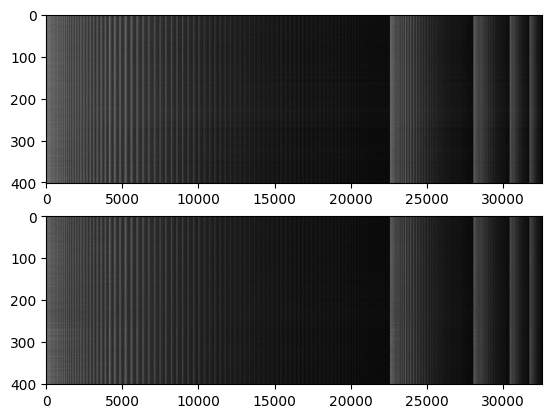

In [126]:
t_idx = [1,3,5,7,9]

sig1 = registrator.registered_frames[:,roi]
sigA = sig0 / np.mean(sig0,axis=1,keepdims=True)

#plt.figure(figsize=(4,4))
fig, axes = plt.subplots(nrows=2, ncols=1)#, gridspec_kw={"height_ratios": [1]})
#axes[0].imshow(registrator.registered_frames[t_idx[0]],cmap='gray')
#axes[1].imshow(registrator.registered_frames[t_idx[1]],cmap='gray')

axes[0].imshow(sig0,cmap='gray',aspect='auto')
axes[1].imshow(sig0n,cmap='gray',aspect='auto')

epaisseur de la choroide : 41 -> 74 px (mediane 65)
A-scans gardes : 382  (76 par colonne de region)
traces par region (toutes echelles / block 1) :
  #0   couche 0  colonne 0  :   2554 /   1790
  #1   couche 0  colonne 1  :   2418 /   1687
  #2   couche 0  colonne 2  :   2507 /   1736
  #3   couche 0  colonne 3  :   1868 /   1317
  #4   couche 0  colonne 4  :   1591 /   1126
  #5   couche 1  colonne 0  :   2557 /   1762
  #6   couche 1  colonne 1  :   2442 /   1670
  #7   couche 1  colonne 2  :   2507 /   1714
  #8   couche 1  colonne 3  :   1886 /   1293
  #9   couche 1  colonne 4  :   1599 /   1097
  #10  couche 2  colonne 0  :   2482 /   1737
  #11  couche 2  colonne 1  :   2366 /   1641
  #12  couche 2  colonne 2  :   2435 /   1683
  #13  couche 2  colonne 3  :   1819 /   1261
  #14  couche 2  colonne 4  :   1524 /   1065


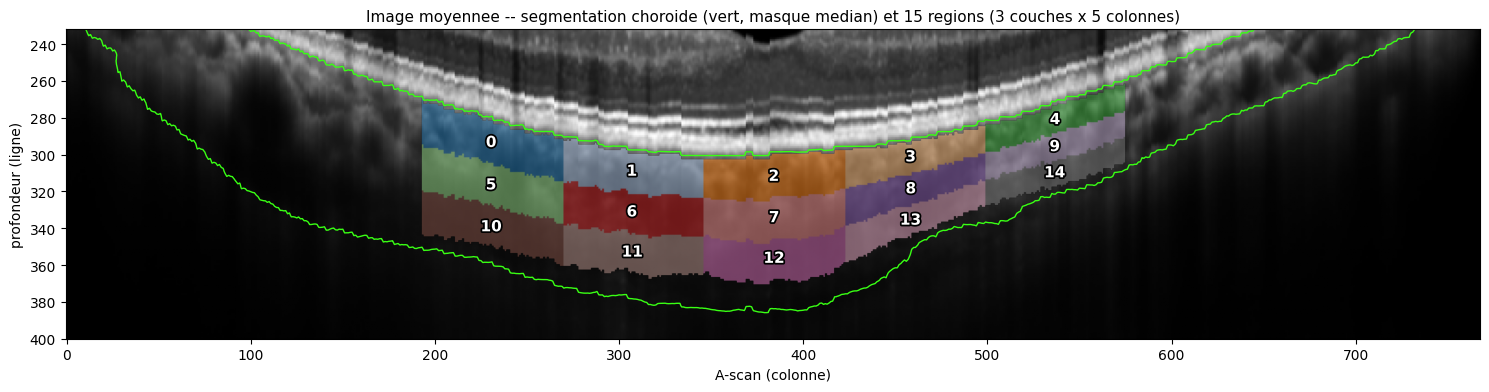

In [127]:
# --- Decoupage de la choroide en N_LAYERS x N_COLS_REG regions ---------------
# Numerotation : region = couche * N_COLS_REG + colonne, donc #0-4 = couche
# superieure (gauche -> droite), #5-9 = mediane, #10-14 = inferieure. C'est
# aussi l'ordre des sous-graphes dans toutes les figures qui suivent.
roi = source.base_roi

# `as_image` lit `roi` et `_BOX` a l'appel : on rafraichit la boite englobante
# ici, au cas ou COL_FRAC/ROW_FRAC aient change depuis la cellule des helpers.
_rows = np.where(roi.any(axis=1))[0]
_cols = np.where(roi.any(axis=0))[0]
_BOX = (slice(_rows.min(), _rows.max() + 1), slice(_cols.min(), _cols.max() + 1))

# Colonnes : parts egales de l'etendue d'A-scans effectivement gardee.
col_group_of_x = np.full(roi.shape[1], -1, dtype=int)
_rank = np.arange(_cols.size) / _cols.size
col_group_of_x[_cols] = np.minimum((_rank * N_COLS_REG).astype(int), N_COLS_REG - 1)

# Couches : tiers de l'epaisseur LOCALE. La choroide n'a ni la meme epaisseur
# ni la meme profondeur d'un A-scan a l'autre -- un decoupage en lignes fixes
# melangerait les couches d'une colonne a l'autre.
region_of_pixel = np.full(roi.shape, -1, dtype=int)
thickness_px = np.zeros(_cols.size)
for j, x in enumerate(_cols):
    rows = np.where(roi[:, x])[0]
    span = rows[-1] - rows[0] + 1
    thickness_px[j] = span
    layer = np.minimum(((rows - rows[0]) / span * N_LAYERS).astype(int), N_LAYERS - 1)
    region_of_pixel[rows, x] = layer * N_COLS_REG + col_group_of_x[x]

# Region de CHAQUE colonne de sig0/sig0n, toutes echelles de bloc confondues.
# `raw_signal` concatene les echelles dans l'ordre de BLOCK_SIZES, chaque bloc
# etant garde seulement s'il est entierement dans la ROI -> son pixel central
# est donc toujours dans la ROI, et sa region est bien definie.
_region_of_trace = []
for b in BLOCK_SIZES:
    roi_b = PixelTraceSource._block_all(roi, b)
    if int(roi_b.sum()) == 0:
        continue                                  # meme saut que raw_signal()
    if b == 1:
        reg_b = region_of_pixel
    else:
        h, w = roi.shape
        hc, wc = h - h % b, w - w % b
        reg_b = region_of_pixel[b // 2:hc:b, b // 2:wc:b]   # pixel central
    _region_of_trace.append(reg_b[roi_b])
region_of_trace = np.concatenate(_region_of_trace)
assert region_of_trace.size == sig0.shape[1], "desalignement traces <-> regions"
assert (region_of_trace >= 0).all(), "des traces hors region"

# Position image de chaque trace block-1 (-1 pour les autres echelles) : sert a
# reprojeter les motifs spatiaux V dans le plan de l'image.
pix_rc = np.argwhere(roi)                          # ordre C = ordre des colonnes
pix_index_of_trace = np.full(region_of_trace.size, -1, dtype=int)
pix_index_of_trace[np.where(is1)[0]] = np.arange(pix_rc.shape[0])

print(f"epaisseur de la choroide : {thickness_px.min():.0f} -> {thickness_px.max():.0f} px "
      f"(mediane {np.median(thickness_px):.0f})")
print(f"A-scans gardes : {_cols.size}  ({_cols.size / N_COLS_REG:.0f} par colonne de region)")
print("traces par region (toutes echelles / block 1) :")
for r in range(N_REGIONS):
    m = region_of_trace == r
    print(f"  #{r:<3d} couche {r // N_COLS_REG}  colonne {r % N_COLS_REG}  :"
          f" {int(m.sum()):>6d} / {int((m & is1).sum()):>6d}")

# --- Figure : image moyennee + segmentation + les 15 regions numerotees -------
mean_frame = registrator.registered_frames.mean(axis=0)
mask_prob = registrator.registered_masks.astype(bool).mean(axis=0)
CMAP_REG = plt.get_cmap("tab20")

fig, ax = plt.subplots(figsize=(15, 5.0))
ax.imshow(mean_frame, cmap="gray")
cs = ax.contour(mask_prob, levels=[0.5], colors="#39ff14", linewidths=1.0)
overlay = np.zeros((*roi.shape, 4))
for r in range(N_REGIONS):
    overlay[region_of_pixel == r] = (*CMAP_REG(r % 20)[:3], 0.50)
ax.imshow(overlay)
for r in range(N_REGIONS):
    rc = np.argwhere(region_of_pixel == r)
    if rc.size == 0:
        continue
    ax.text(rc[:, 1].mean(), rc[:, 0].mean(), str(r),
            color="white", fontsize=11, fontweight="bold", ha="center", va="center",
            path_effects=[pe.withStroke(linewidth=2.5, foreground="black")])
MARGIN = 30
ax.set_ylim(min(_rows.max() + MARGIN, roi.shape[0] - 1), max(_rows.min() - MARGIN, 0))
ax.set_title(f"Image moyennee -- segmentation choroide (vert, masque median) et "
             f"{N_REGIONS} regions ({N_LAYERS} couches x {N_COLS_REG} colonnes)",
             fontsize=11)
ax.set_xlabel("A-scan (colonne)")
ax.set_ylabel("profondeur (ligne)")
fig.tight_layout()


#0   pic =  188.8 BPM   en bande = 15.10%
#1   pic =   31.4 BPM   en bande = 16.44%
#2   pic =   61.8 BPM   en bande = 20.27%  <-- pic en bande
#3   pic =   88.6 BPM   en bande = 15.47%
#4   pic =   70.6 BPM   en bande = 15.20%  <-- pic en bande
#5   pic =   85.1 BPM   en bande = 11.59%
#6   pic =  142.6 BPM   en bande = 14.67%
#7   pic =  176.1 BPM   en bande = 13.42%
#8   pic =   21.8 BPM   en bande = 15.12%
#9   pic =   55.6 BPM   en bande = 16.64%  <-- pic en bande
#10  pic =   88.6 BPM   en bande = 16.27%
#11  pic =  176.1 BPM   en bande = 15.05%
#12  pic =  188.8 BPM   en bande = 14.73%
#13  pic =   31.9 BPM   en bande = 19.08%
#14  pic =   32.3 BPM   en bande = 13.91%


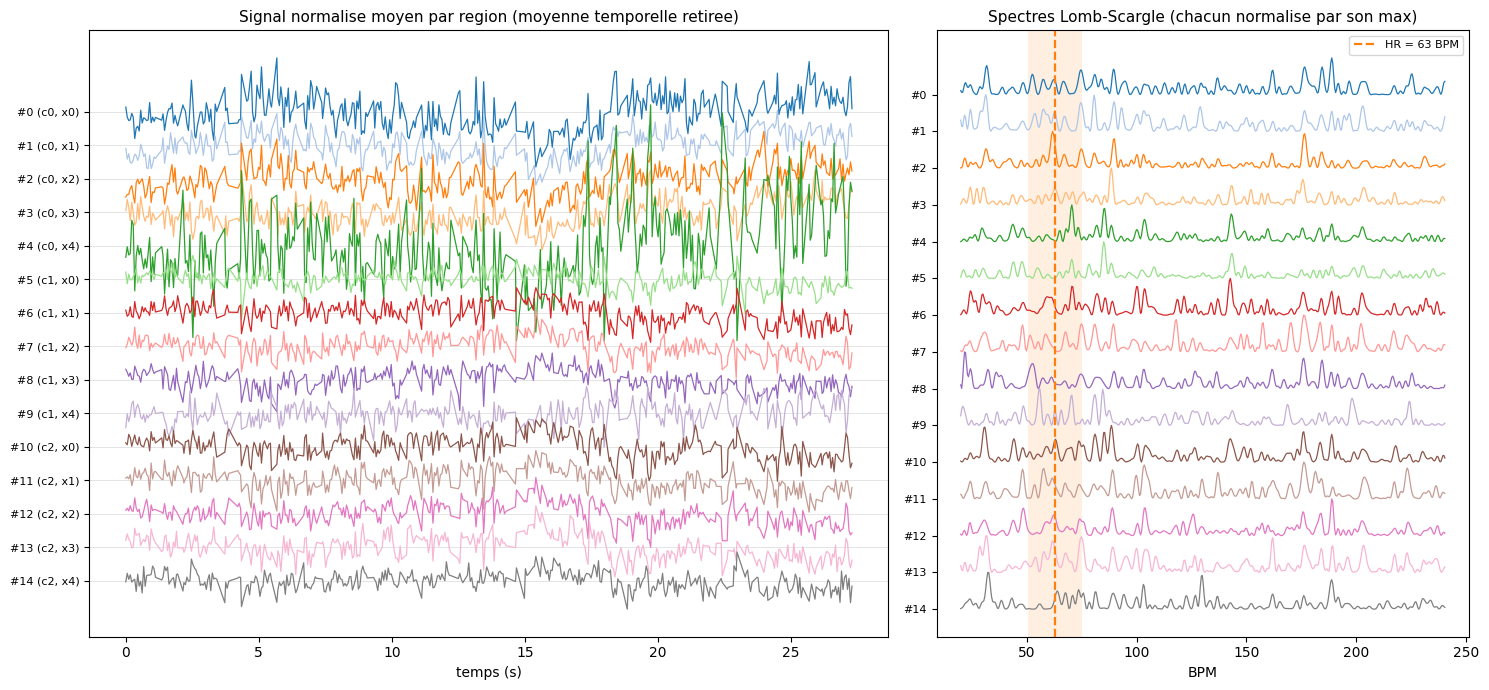

In [128]:
# --- Signal normalise de chaque region ---------------------------------------
# Une trace par region = moyenne de ses colonnes de `sig0n` (toutes echelles de
# bloc). Sert de reference de signe plus bas : la combinaison optimisee d'une
# region sera retournee pour correler positivement avec elle.
sig_reg = np.stack(
    [np.nanmean(sig0n[:, region_of_trace == r], axis=1) for r in range(N_REGIONS)],
    axis=1,
)                                                     # (T, N_REGIONS)
P_reg = np.stack([spectrum(sig_reg[:, r]) for r in range(N_REGIONS)], axis=1)
peak_reg = bpm_axis[P_reg.argmax(axis=0)]
frac_reg = P_reg[in_band].sum(axis=0) / (P_reg.sum(axis=0) + 1e-12)

for r in range(N_REGIONS):
    flag = "  <-- pic en bande" if in_band[P_reg[:, r].argmax()] else ""
    print(f"#{r:<3d} pic = {peak_reg[r]:6.1f} BPM   en bande = {frac_reg[r]:6.2%}{flag}")

fig, axes = plt.subplots(1, 2, figsize=(15, 7), gridspec_kw={"width_ratios": [1.5, 1]})

vals = sig_reg - sig_reg.mean(axis=0, keepdims=True)
step = 3.0 * float(np.median(vals.std(axis=0))) + 1e-12
for r in range(N_REGIONS):
    off = (N_REGIONS - 1 - r) * step                  # #0 en haut, comme l'image
    axes[0].plot(t, vals[:, r] + off, lw=0.9, color=CMAP_REG(r % 20))
    axes[0].axhline(off, color="0.85", lw=0.5, zorder=0)
axes[0].set_yticks([(N_REGIONS - 1 - r) * step for r in range(N_REGIONS)])
axes[0].set_yticklabels([f"#{r} (c{r // N_COLS_REG}, x{r % N_COLS_REG})"
                         for r in range(N_REGIONS)], fontsize=8)
axes[0].set_title("Signal normalise moyen par region (moyenne temporelle retiree)",
                  fontsize=11)
axes[0].set_xlabel("temps (s)")

for r in range(N_REGIONS):
    off = (N_REGIONS - 1 - r) * 1.0
    Pr = P_reg[:, r]
    axes[1].plot(bpm_axis, Pr / (Pr.max() + 1e-12) + off, lw=0.9,
                 color=CMAP_REG(r % 20))
mark_hr(axes[1])
axes[1].set_yticks(np.arange(N_REGIONS))
axes[1].set_yticklabels([f"#{N_REGIONS - 1 - k}" for k in range(N_REGIONS)], fontsize=8)
axes[1].set_title("Spectres Lomb-Scargle (chacun normalise par son max)", fontsize=11)
axes[1].set_xlabel("BPM")
axes[1].legend(fontsize=8)
fig.tight_layout()


#0     2554 traces  ->  20 composantes, 7 piquent en bande
#1     2418 traces  ->  20 composantes, 5 piquent en bande
#2     2507 traces  ->  20 composantes, 14 piquent en bande
#3     1868 traces  ->  20 composantes, 8 piquent en bande
#4     1591 traces  ->  20 composantes, 9 piquent en bande
#5     2557 traces  ->  20 composantes, 3 piquent en bande
#6     2442 traces  ->  20 composantes, 6 piquent en bande
#7     2507 traces  ->  20 composantes, 4 piquent en bande
#8     1886 traces  ->  20 composantes, 6 piquent en bande
#9     1599 traces  ->  20 composantes, 9 piquent en bande
#10    2482 traces  ->  20 composantes, 5 piquent en bande
#11    2366 traces  ->  20 composantes, 4 piquent en bande
#12    2435 traces  ->  20 composantes, 5 piquent en bande
#13    1819 traces  ->  20 composantes, 5 piquent en bande
#14    1524 traces  ->  20 composantes, 3 piquent en bande


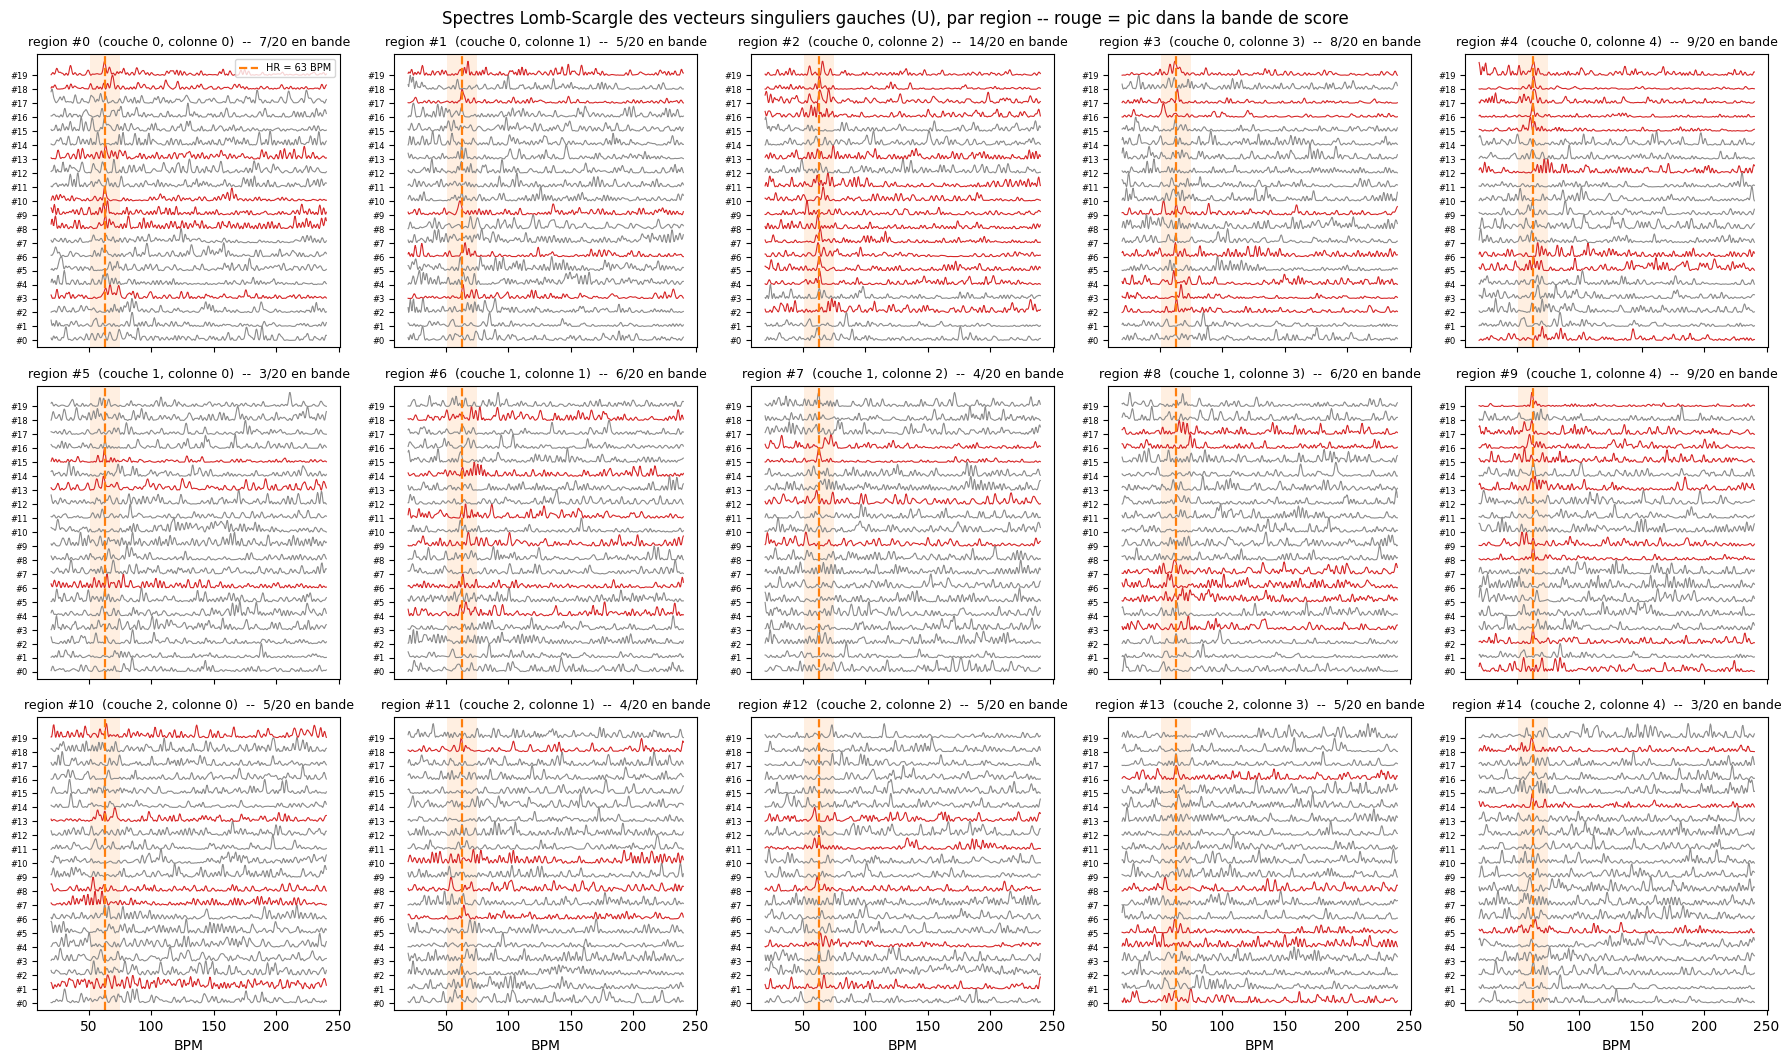

In [129]:
# --- SVD, une par region -----------------------------------------------------
svd_reg = {}
for r in range(N_REGIONS):
    cols_r = np.where(region_of_trace == r)[0]
    Xr = np.nan_to_num(sig0n[:, cols_r], nan=0.0)
    k = int(min(N_SVD_REGION, Xr.shape[0], Xr.shape[1]))
    Ur, Vr = project_into_separable_components(
        Xr,
        method="svd",
        n_components=k,
        normalize=False,      # True = centre chaque colonne avant la SVD
        random_state=0,
    )
    # Ur : (T, k) = U * S, composantes temporelles
    # Vr : (N_r, k) = V, motif spatial de chaque composante
    Pr = np.stack([spectrum(Ur[:, i]) for i in range(k)], axis=1)   # (F, k)
    jmax = Pr.argmax(axis=0)
    svd_reg[r] = {
        "cols": cols_r,
        "U": Ur,
        "V": Vr,
        "P": Pr,
        "peak_bpm": bpm_axis[jmax],
        "in_band": in_band[jmax],
        "frac": Pr[in_band].sum(axis=0) / (Pr.sum(axis=0) + 1e-12),
    }
    print(f"#{r:<3d} {cols_r.size:>6d} traces  ->  {k} composantes, "
          f"{int(svd_reg[r]['in_band'].sum())} piquent en bande")

# --- Figure : spectres empiles, un sous-graphe par region --------------------
# La grille reproduit la disposition des regions dans l'image : ligne = couche
# (0 = superieure), colonne = position en x.
fig, axes = plt.subplots(N_LAYERS, N_COLS_REG,
                         figsize=(3.6 * N_COLS_REG, 3.6 * N_LAYERS),
                         sharex=True)
for r in range(N_REGIONS):
    ax = axes[r // N_COLS_REG][r % N_COLS_REG]
    d = svd_reg[r]
    K = d["P"].shape[1]
    for k in range(K):                                 # #0 en bas
        Pk = d["P"][:, k]
        ax.plot(bpm_axis, Pk / (Pk.max() + 1e-12) + k, lw=0.8,
                color="C3" if d["in_band"][k] else "0.55")
    mark_hr(ax)
    ax.set_title(f"region #{r}  (couche {r // N_COLS_REG}, colonne {r % N_COLS_REG})"
                 f"  --  {int(d['in_band'].sum())}/{K} en bande", fontsize=9)
    ax.set_yticks(np.arange(K))
    ax.set_yticklabels([f"#{k}" for k in range(K)], fontsize=6)
    ax.set_ylim(-0.5, K + 0.5)
    if r // N_COLS_REG == N_LAYERS - 1:
        ax.set_xlabel("BPM")
axes[0][0].legend(fontsize=7, loc="upper right")
fig.suptitle("Spectres Lomb-Scargle des vecteurs singuliers gauches (U), par region "
             "-- rouge = pic dans la bande de score", fontsize=12)
fig.tight_layout()


passe-bande : 50.4-75.6 BPM (0.840-1.260 Hz)  |  fs = 17.86 Hz, cutoffs normalises = 0.0941/0.1411

#0    3 candidates -> pic   63.1 BPM, en bande 52.96% (vs 45.07% pour la meilleure seule #20), objectif -0.0345,   0.3 s
#1    3 candidates -> pic   64.8 BPM, en bande 37.06% (vs 34.00% pour la meilleure seule #23), objectif -0.0150,   0.2 s
#2    4 candidates -> pic   63.1 BPM, en bande 43.12% (vs 31.96% pour la meilleure seule #26), objectif -0.0244,   0.3 s
#3    6 candidates -> pic   63.1 BPM, en bande 48.19% (vs 30.80% pour la meilleure seule #17), objectif -0.0289,   0.7 s
#4    4 candidates -> pic   63.1 BPM, en bande 46.39% (vs 27.57% pour la meilleure seule #19), objectif -0.0268,   0.4 s
#5    2 candidates -> pic   63.1 BPM, en bande 29.08% (vs 27.58% pour la meilleure seule #15), objectif -0.0094,   0.1 s
#6    1 candidates -> pic   62.2 BPM, en bande 32.66% (vs 32.66% pour la meilleure seule #19), objectif -0.0118,   0.0 s
#7   ECHEC : No candidate trace has a peak within 12.

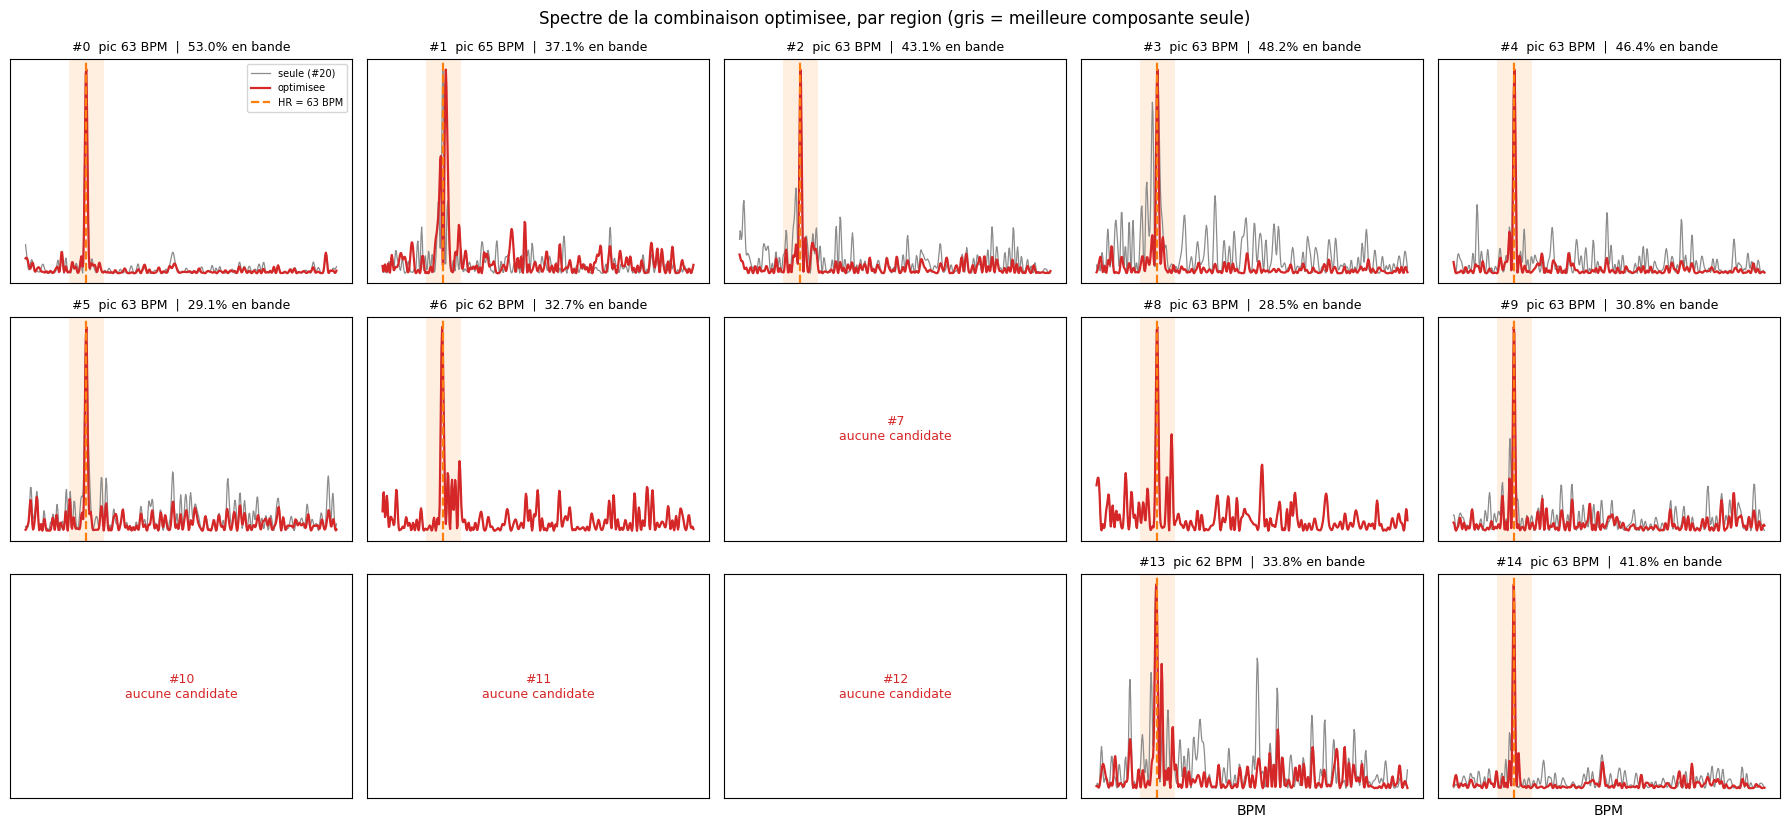

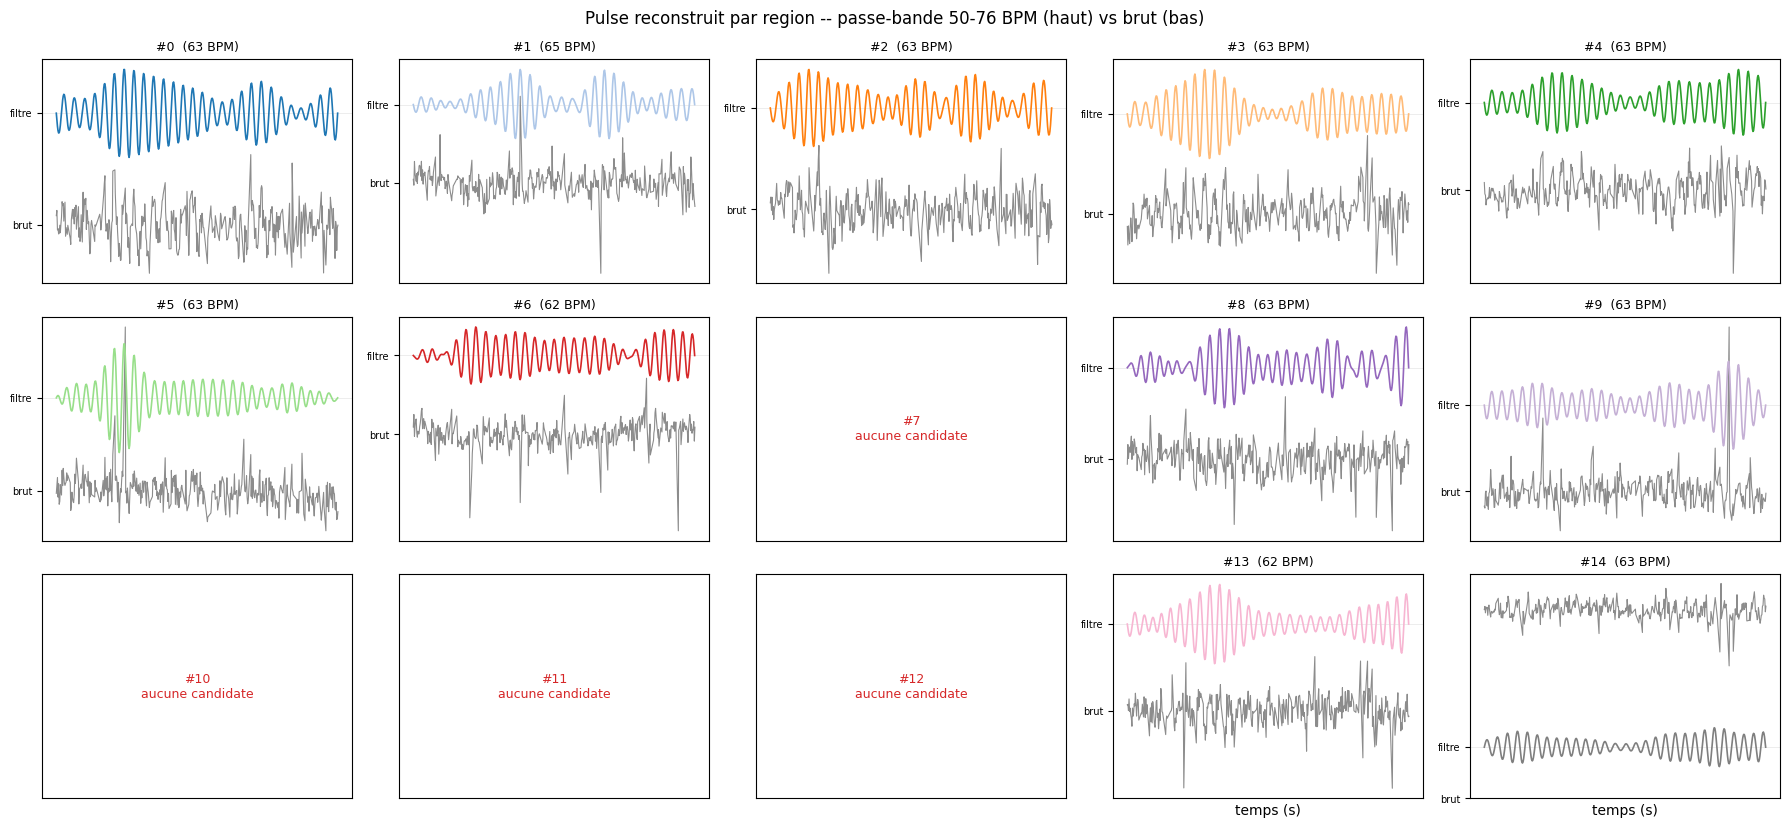

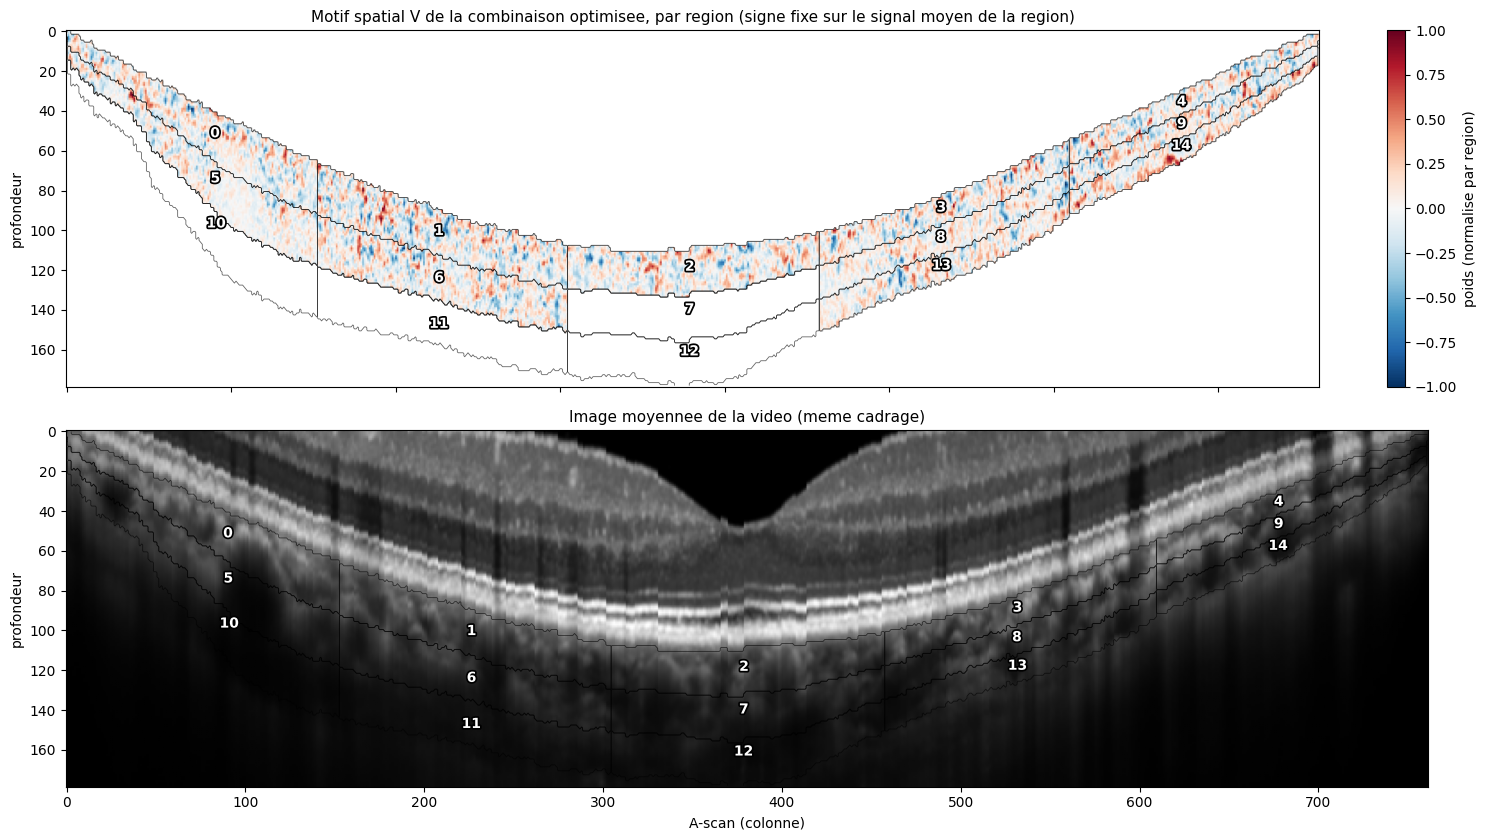

In [ ]:
# --- Optimisation de la combinaison, une par region --------------------------
from ocularrigidity.motion.pulsation.traces import Traces
from ocularrigidity.motion.pulsation.rate import (
    LombScargleConfig,
    LombScargleRateEstimator,
)
from ocularrigidity.motion.pulsation.phase import (
    OptimizedSpectralCombination,
    SpectralCombinationConfig,
)
from ocularrigidity.motion.filters._1d import spatio_temporal_filter

# Bande LARGE pour le rate estimator : son `freqs` sert aussi de grille
# hors-bande dans l'objectif (e_out). Avec `band` (+/-BAND_FRAC de la HR) il n'y
# aurait presque aucun point hors bande et le rapport a maximiser serait
# degenere. `override_bpm` fixe la cible a la HR mesuree, sans re-estimation.
RATE_EST = LombScargleRateEstimator(
    LombScargleConfig(band=CardiacBand(bpm_range=DIAG_BPM_RANGE), verbose=False),
    override_bpm=float(hr),
)
# n_restarts/maxiter reduits : l'objectif recalcule un Lomb-Scargle complet a
# chaque evaluation, et on optimise 15 fois. Remonter pour un run "propre".
OPT_CFG = SpectralCombinationConfig(
    accept_tol_bpm=BAND_FRAC * hr,     # meme bande que `in_band`
    min_concentration=0.15,
    max_candidates=12,
    n_restarts=4,
    maxiter=100,
    random_state=0,
)

# --- Passe-bande : exactement celui de la chaine de reconstruction -----------
# `AbstractUniformTraceSource.filtered_signal` (base.py:217) appelle
# `spatio_temporal_filter` avec des frequences de coupure normalisees par
# Nyquist et la bande physiologique `band`. Meme fonction, memes cutoffs, sans
# lissage spatial (on filtre une trace unique).
_NYQ = 0.5 * aligner.fs
_LO_BPM, _HI_BPM = band.effective_bpm_range
_LOW = (_LO_BPM / 60.0) / _NYQ
_HIGH = min((_HI_BPM / 60.0) / _NYQ, 0.99)
u_time = aligner.uniform_time


def bandpass_pulse(y):
    """Passe-bande cardiaque sur une trace unique.

    Le FIR suppose un echantillonnage uniforme ; `y` vit sur les horodatages
    reels `t`, qui ne le sont pas. On l'interpole donc d'abord sur la grille de
    l'aligner -- exactement ce que fait `filtered_signal`, qui filtre
    `interpolated_signal` et non le signal brut. Le resultat vit sur `u_time`.
    """
    yu = np.interp(u_time, t, y)
    return spatio_temporal_filter(
        yu[:, None],
        spatial_sigma=0.0,
        temporal_low_freq=_LOW,
        temporal_high_freq=_HIGH,
        fs=aligner.fs,
        validity_mask=None,
    )[:, 0]


print(f"passe-bande : {_LO_BPM:.1f}-{_HI_BPM:.1f} BPM "
      f"({_LO_BPM / 60:.3f}-{_HI_BPM / 60:.3f} Hz)  |  fs = {aligner.fs:.2f} Hz, "
      f"cutoffs normalises = {_LOW:.4f}/{_HIGH:.4f}\n")

opt_reg = {}
for r in range(N_REGIONS):
    d = svd_reg[r]
    traces_r = Traces(
        values=np.asarray(d["U"], dtype=np.float64),
        uniform_time=t,
        kept_mask=np.ones(t.size, dtype=bool),
        gap_mask=np.zeros(t.size, dtype=bool),
        timestamps_seconds=t,
        mixing=np.asarray(d["V"], dtype=np.float64),
    )
    rate_r = RATE_EST.estimate(traces_r)
    agg_r = OptimizedSpectralCombination(OPT_CFG)
    t0 = time.perf_counter()
    try:
        y = agg_r.aggregate(traces_r, rate_r)
    except ValueError as exc:
        opt_reg[r] = None
        print(f"#{r:<3d} ECHEC : {exc}")
        continue
    res_r = agg_r.last_result
    pattern = res_r.spatial_pattern

    # Le signe d'une SVD est arbitraire : on le fixe pour que la combinaison
    # correle positivement avec le signal moyen de la region. Sans ca les
    # motifs spatiaux de deux regions voisines ne sont pas comparables.
    c = np.corrcoef(y, sig_reg[:, r])[0, 1]
    if np.isfinite(c) and c < 0:
        y, pattern = -y, -pattern

    P_y = spectrum(y)
    k_best = int(res_r.selected_indices[np.argmax(d["frac"][res_r.selected_indices])])
    opt_reg[r] = {
        "y": y,                              # sur `t` (horodatages reels)
        "y_filt": bandpass_pulse(y),         # sur `u_time` (grille uniforme)
        "P": P_y,
        "pattern": pattern,
        "frac": float(P_y[in_band].sum() / (P_y.sum() + 1e-12)),
        "peak_bpm": float(bpm_axis[P_y.argmax()]),
        "selected": res_r.selected_indices,
        "weights": res_r.weights,
        "objective": res_r.objective,
        "k_best": k_best,
    }
    print(f"#{r:<3d} {res_r.selected_indices.size:>2d} candidates -> pic "
          f"{opt_reg[r]['peak_bpm']:6.1f} BPM, en bande {opt_reg[r]['frac']:6.2%} "
          f"(vs {d['frac'][k_best]:6.2%} pour la meilleure seule #{k_best}), "
          f"objectif {res_r.objective:+.4f}, {time.perf_counter() - t0:5.1f} s")


def _grid(title):
    fig, axes = plt.subplots(N_LAYERS, N_COLS_REG,
                             figsize=(3.6 * N_COLS_REG, 2.8 * N_LAYERS), sharex=True)
    fig.suptitle(title, fontsize=12)
    return fig, axes


def _empty(ax, r):
    ax.text(0.5, 0.5, f"#{r}\naucune candidate", ha="center", va="center",
            transform=ax.transAxes, fontsize=9, color="C3")
    ax.set_xticks([])
    ax.set_yticks([])


# --- Spectres de la combinaison optimisee ------------------------------------
fig, axes = _grid("Spectre de la combinaison optimisee, par region "
                  "(gris = meilleure composante seule)")
for r in range(N_REGIONS):
    ax = axes[r // N_COLS_REG][r % N_COLS_REG]
    o = opt_reg[r]
    if o is None:
        _empty(ax, r)
        continue
    Pb = svd_reg[r]["P"][:, o["k_best"]]
    ax.plot(bpm_axis, Pb / (Pb.max() + 1e-12), lw=0.9, color="0.55",
            label=f"seule (#{o['k_best']})")
    ax.plot(bpm_axis, o["P"] / (o["P"].max() + 1e-12), lw=1.6, color="C3",
            label="optimisee")
    mark_hr(ax)
    ax.set_title(f"#{r}  pic {o['peak_bpm']:.0f} BPM  |  {o['frac']:.1%} en bande",
                 fontsize=9)
    ax.set_yticks([])
    if r // N_COLS_REG == N_LAYERS - 1:
        ax.set_xlabel("BPM")
axes[0][0].legend(fontsize=7)
fig.tight_layout()

# --- Pulse reconstruit : filtre (haut) vs brut (bas) -------------------------
# Les deux traces sont reduites (divisees par leur ecart-type) avant d'etre
# decalees : le passe-bande retire une partie de la variance, les tracer a la
# meme echelle absolue ecraserait le filtre. On compare des FORMES.
PULSE_OFFSET = 0.0
fig, axes = _grid(f"Pulse reconstruit par region -- passe-bande "
                  f"{_LO_BPM:.0f}-{_HI_BPM:.0f} BPM (haut) vs brut (bas)")
for r in range(N_REGIONS):
    ax = axes[r // N_COLS_REG][r % N_COLS_REG]
    o = opt_reg[r]
    if o is None:
        _empty(ax, r)
        continue
    yn = o["y"] / (np.nanstd(o["y"]) + 1e-9)
    yf = o["y_filt"] / (np.nanstd(o["y_filt"]) + 1e-9)
    ax.axhline(PULSE_OFFSET, color="0.9", lw=0.5, zorder=0)
    ax.plot(t, yn, lw=0.8, color="0.55")
    ax.plot(u_time, yf + PULSE_OFFSET, lw=1.2, color=CMAP_REG(r % 20))
    ax.set_title(f"#{r}  ({o['peak_bpm']:.0f} BPM)", fontsize=9)
    ax.set_yticks([PULSE_OFFSET, 0.0])
    ax.set_yticklabels(["filtre", "brut"], fontsize=7)
    if r // N_COLS_REG == N_LAYERS - 1:
        ax.set_xlabel("temps (s)")
fig.tight_layout()

# --- Carte des motifs spatiaux (V) vs image moyennee -------------------------
# Chaque region est normalisee par son propre max|.| : les valeurs singulieres
# ne sont pas comparables d'une region a l'autre, seule la STRUCTURE l'est.
Vmap = np.full(roi.shape, np.nan)
for r in range(N_REGIONS):
    o = opt_reg[r]
    if o is None:
        continue
    pi = pix_index_of_trace[svd_reg[r]["cols"]]
    ok = pi >= 0                                   # colonnes block-1 seulement
    p = np.asarray(o["pattern"], dtype=float)[ok]
    Vmap[pix_rc[pi[ok], 0], pix_rc[pi[ok], 1]] = p / (np.abs(p).max() + 1e-12)

fig, axes = plt.subplots(2, 1, figsize=(15, 8.5), sharex=True, sharey=True)
im = axes[0].imshow(Vmap[_BOX], cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
fig.colorbar(im, ax=axes[0], fraction=0.03, label="poids (normalise par region)")
axes[0].set_title("Motif spatial V de la combinaison optimisee, par region "
                  "(signe fixe sur le signal moyen de la region)", fontsize=11)
axes[0].set_ylabel("profondeur")

axes[1].imshow(mean_frame[_BOX], cmap="gray", aspect="auto")
axes[1].set_title("Image moyennee de la video (meme cadrage)", fontsize=11)
axes[1].set_xlabel("A-scan (colonne)")
axes[1].set_ylabel("profondeur")

reg_box = region_of_pixel[_BOX]
for ax in axes:
    for r in range(N_REGIONS):
        m = reg_box == r
        if not m.any():
            continue
        ax.contour(m.astype(float), levels=[0.5], colors="k", linewidths=0.6,
                   alpha=0.6)
        rc = np.argwhere(m)
        ax.text(rc[:, 1].mean(), rc[:, 0].mean(), str(r), color="white", fontsize=10,
                fontweight="bold", ha="center", va="center",
                path_effects=[pe.withStroke(linewidth=2.5, foreground="black")])
fig.tight_layout()
